In [121]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
datosGeneracion = pd.read_csv(r"Plant_1_Generation_Data.csv")
datosMeteorologia = pd.read_csv(r"Plant_1_Weather_Sensor_Data.csv")


Una vez cargadas, visualizamos la info de los dos csv para poder juntarlos

In [122]:
print(datosGeneracion.info())
print(datosMeteorologia.info())

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  str    
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  str    
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 3.7 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   str    
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   str    
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION 

En primer lugar transformamos todas las fechas a formato DATE_TIME

In [123]:
datosGeneracion['DATE_TIME'] = pd.to_datetime(datosGeneracion['DATE_TIME'])
datosMeteorologia['DATE_TIME'] = pd.to_datetime(datosMeteorologia['DATE_TIME'])

/tmp/ipykernel_66266/3995665072.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  datosGeneracion['DATE_TIME'] = pd.to_datetime(datosGeneracion['DATE_TIME'])


Luego cruzamos los datos de las tablas

In [124]:
datosUnidos= pd.merge(datosMeteorologia,datosGeneracion,on='DATE_TIME',how = 'inner')
datosUnidos = datosUnidos.sort_values(by=['SOURCE_KEY_y', 'DATE_TIME'])
datosUnidos = datosUnidos.set_index('DATE_TIME')
print(datosUnidos.shape)
print(datosMeteorologia.shape)


(68774, 11)
(3182, 6)


Eliminamos una de las columnas de id de las plantas al estar duplicadas

In [125]:
datosUnidos = datosUnidos.drop(columns=['PLANT_ID_x'])


En primer lugar hacemos una funcion para detectar valores imposibles que provienen de fallos de los sensores y mediante una interpolación temporal hacemos que los NaN se rellenen automáticamente

In [126]:
def fueraRango(valor, min_val, max_val):
    if valor < min_val or valor > max_val:
        return np.nan
    return valor
        
datosUnidos['DC_POWER'] = datosUnidos['DC_POWER'].apply(
    fueraRango, 
    min_val=0, 
    max_val=15000
)
datosUnidos['DC_POWER'] = datosUnidos.groupby('SOURCE_KEY_y')['DC_POWER'].transform(
    lambda x: x.interpolate(method='time')
)

Contamos cuantas mediciones se han hecho por hora

In [127]:
datosUnidos['TRAMO_HORARIO'] = datosUnidos.index.floor('h') 
ranking_tramos = datosUnidos['TRAMO_HORARIO'].value_counts().reset_index(name='frecuencia')
print(ranking_tramos)

          TRAMO_HORARIO  frecuencia
0   2020-05-15 07:00:00          88
1   2020-05-15 08:00:00          88
2   2020-05-15 09:00:00          88
3   2020-05-15 10:00:00          88
4   2020-05-15 11:00:00          88
..                  ...         ...
791 2020-06-04 19:00:00          40
792 2020-05-15 23:00:00          22
793 2020-05-21 07:00:00          22
794 2020-05-23 05:00:00          22
795 2020-05-23 06:00:00          22

[796 rows x 2 columns]


Buscamos las que más y menos generan de media

<Axes: xlabel='SOURCE_KEY_y'>

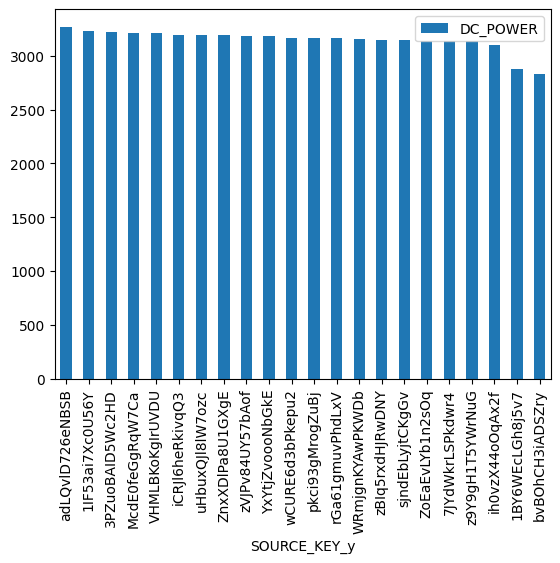

In [128]:
media = datosUnidos.groupby('SOURCE_KEY_y')['DC_POWER'].mean()
media = media.sort_values(ascending= False)
media.plot.bar(legend=True)


Ahora vamos a ver la relación entre la producción y la irradiación solar. Como nota debemos subrayar que los datos "extraños" que observamos en el eje vertical izquierdo del gráfico de disperión en los que la radiación solar es mayor a 0 pero no se genera potencia no se han eliminado al ser muy útiles para encontrar fallos operativos en los inversores

La correlación entre las dos variables es de 0.9893910408878281 lo que indica alta correlación


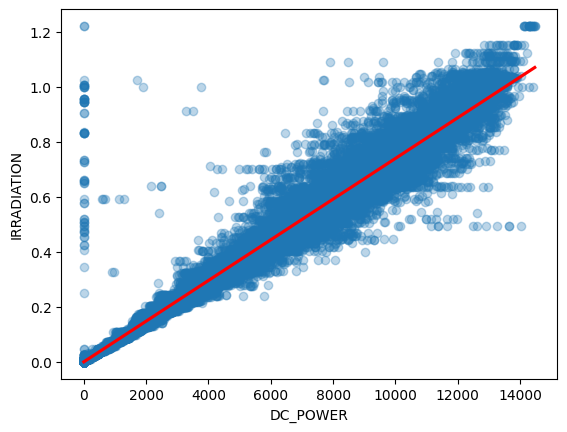

In [129]:
correlacionIrradiacion = datosUnidos['DC_POWER'].corr(datosUnidos['IRRADIATION'])
sns.regplot(data=datosUnidos,x='DC_POWER',y= 'IRRADIATION',scatter_kws={'alpha':0.3},line_kws={'color':'red'})
print (f"La correlación entre las dos variables es de {correlacionIrradiacion} lo que indica alta correlación")

¿Qué es más importante para la generación, la temperatura del modulo, la ambiente o la irradiación?

Irradiación : 0.9893910408878281
Temp. Módulo : 0.9548110519171338
Temp. Ambiente : 0.7246681124355113


<Axes: xlabel='COEFICIENTE', ylabel='VARIABLE'>

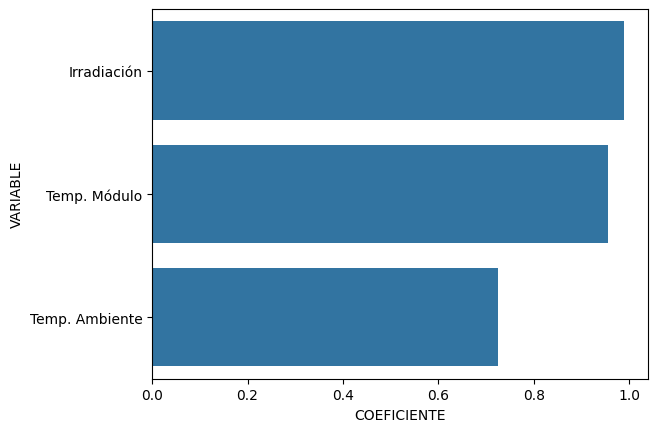

In [130]:
correlacionTempAmb = datosUnidos['DC_POWER'].corr(datosUnidos['AMBIENT_TEMPERATURE'])
corrrelacionTempMod = datosUnidos['DC_POWER'].corr(datosUnidos['MODULE_TEMPERATURE'])

lista_corr = [
    ("Irradiación", correlacionIrradiacion),
    ("Temp. Ambiente", correlacionTempAmb),
    ("Temp. Módulo", corrrelacionTempMod)
]

lista_corr.sort(key=lambda x: x[1], reverse=True)

for nombre, valor in lista_corr:
    print(f"{nombre} : {valor}")
correlaciones = pd.DataFrame(lista_corr,columns=['VARIABLE','COEFICIENTE'])
sns.barplot(data=correlaciones,x='COEFICIENTE',y='VARIABLE')

Sabiendo ya la importancia de la irradiación, compararemos la irradiación con la generación

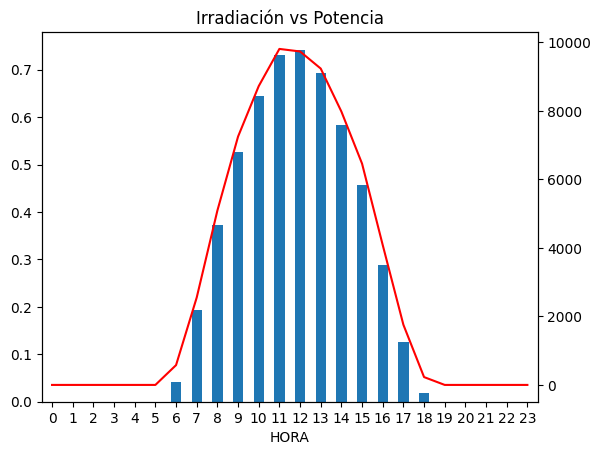

In [146]:
# 1. Agrupar (ya lo tienes)
irrHora = datosUnidos.groupby('HORA')[['IRRADIATION', 'DC_POWER']].mean()

# 2. Graficar la irradiación en barras
ax = irrHora['IRRADIATION'].plot(kind='bar')

# 3. Graficar la potencia en línea usando el mismo eje (secondary_y)
irrHora['DC_POWER'].plot(kind='line', color='red', secondary_y=True, ax=ax)

plt.title('Irradiación vs Potencia')
plt.show()

Desde la empresa nos comunican que ha bajado la potencia mucho en los últimos meses, seguramente provocado por el deterioro o fallo de alguno de los inversores, nos piden localizar los inversores defectuosos para poder repararlos.

Usaremos un ratio de rendimiento calculado sobre la radiación solar para identificar los outliers a la baja que son los que están causando este fallo

In [132]:
# Creamos el resumen por inversor
irrDCComb = datosUnidos.groupby('SOURCE_KEY_y').agg({
    'DC_POWER': 'mean',
    'IRRADIATION': 'mean'
}).reset_index()

irrDCComb['RATIOPROD'] = irrDCComb['DC_POWER'] / irrDCComb['IRRADIATION'] #Primero sacamos un scorage para porder comparar la productividad de las placas

mediana = irrDCComb['RATIOPROD'].median()
#Utilizando el método del rango intercuartílico podemos calcular los outliers a la baja
Q1 = irrDCComb['RATIOPROD'].quantile(0.25)
Q3 = irrDCComb['RATIOPROD'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
inversores_fallando = irrDCComb[irrDCComb['RATIOPROD'] < limite_inferior]
ids_defectuosos = inversores_fallando['SOURCE_KEY_y'].tolist()
print(f"Inversores defectuosos \n {inversores_fallando}")
print(f"La mediana de ratio es de {mediana}")

Inversores defectuosos 
        SOURCE_KEY_y     DC_POWER  IRRADIATION     RATIOPROD
0   1BY6WEcLGh8j5v7  2873.720981     0.230310  12477.635115
11  bvBOhCH3iADSZry  2828.998291     0.230245  12286.930193
La mediana de ratio es de 13613.39090172688


La empresa desea conocer si la restauración de estas plantas sería óptimo o, si en cambio el restaurarlas resultaria en una pérdida de dinero. Para ello nos han pedido una simulación de la generación si se restauran las plantas, sobretodo inquiriendo en que debe ser expuesta de forma muy visual.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
#En primer lugar quitamos los nan para poder tener datos limpios
datosUnidos_ml = datosUnidos.dropna(subset=['AMBIENT_TEMPERATURE', 'IRRADIATION', 'DC_POWER'])  
#Luego quitamos las placas que sabemos que están defectuosas ya que ensuciarian nuestra predicción
datos_entrenamiento = datosUnidos_ml[~datosUnidos_ml['SOURCE_KEY_y'].isin(ids_defectuosos)]
#Aunque lo ideal sería consultar con un especialista, al considerar la temperatura del módulo una variable totalmente relacionada con la irradiacion y la temperatura ambiente 
#he considerado que no aportaría nada a nuestra predicción, de forma que consideramos solo la temperatura ambiente y la irradiación
X = datos_entrenamiento[['AMBIENT_TEMPERATURE', 'IRRADIATION']]
y = datos_entrenamiento['DC_POWER']
#Dividimos los datos para entrenamiento y para test, un 75/25
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=8)
#Modelamos un random forest*
modelo_inversor = RandomForestRegressor(n_estimators=100, random_state=8)
modelo_inversor.fit(X_train, y_train)

#Probamos nuestro modelo
predicciones = modelo_inversor.predict(X_test)
error = mean_absolute_error(y_test, predicciones)

print(f"El error medio de mi Gemelo Digital es de: {error:.2f} kW")

#*Elegimos un random forest y no una regresión lineal ya que, como se puede comprobar en el gráfico Irradiación vs Potencia, aunque estén claramente relacionadas
# observandose el gráfico, el pico de generación no coincide con el de de irradiación, denotandonos un comportamiento más complejo que una regresión, por lo que 
# para hacer un modelo fidedigno usamos un modelo de Bosque Aleatorio.

El error medio de mi Gemelo Digital es de: 146.72 kW


Ahora aplicamos el Gemelo Digital y estimamos la potencia generada si arreglasemos las placas

In [ ]:
#Preparamos los datos de los inversores defectuosos

datos_test = datosUnidos.loc[
    datosUnidos['SOURCE_KEY_y'].isin(ids_defectuosos), 
    ['SOURCE_KEY_y', 'AMBIENT_TEMPERATURE', 'IRRADIATION']
].dropna() 

#Aplicamos nuestro modelo a estos inversores

Kw_restauracion = modelo_inversor.predict(
    datos_test[['AMBIENT_TEMPERATURE', 'IRRADIATION']]
)
datos_test['DC_POWER_TEORICO'] = Kw_restauracion

print("--- Media Teórica por Inversor Defectuoso ---")
print(datos_test.groupby('SOURCE_KEY_y')['DC_POWER_TEORICO'].mean())

print("\n--- Media Real de Toda la Planta (Referencia) ---")
print(datosUnidos['DC_POWER'].mean())

--- Media Teórica por Inversor Defectuoso ---
SOURCE_KEY_y
1BY6WEcLGh8j5v7    2856.424921
bvBOhCH3iADSZry    2855.556374
Name: DC_POWER_TEORICO, dtype: float64

--- Media Real de Toda la Planta (Referencia) ---
3147.1774501376403


Ahora lo representamos para los stake holders

/tmp/ipykernel_66266/3868129610.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Estado', y='Potencia (kW)', data=datos_grafico, palette=['red', 'gray', 'green'])


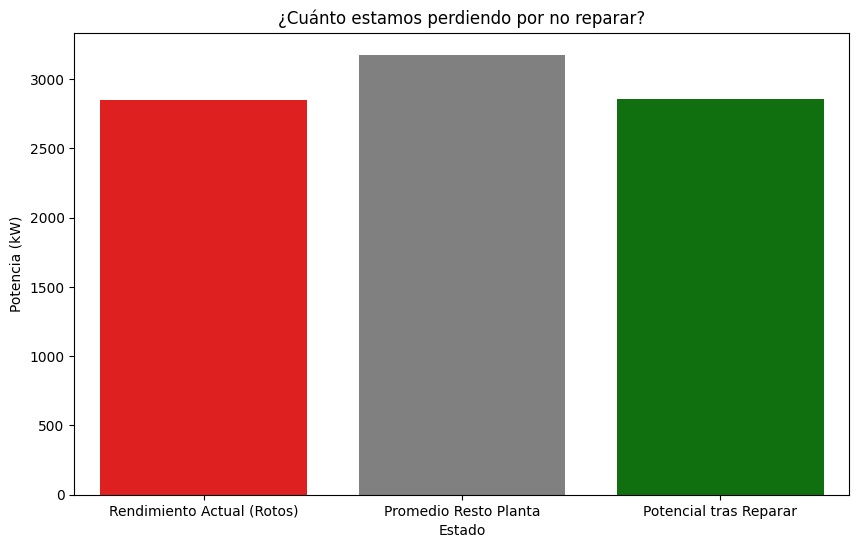

In [ ]:
# 1. Calculamos las tres medias principales
media_plant_sana = datosUnidos.loc[~datosUnidos['SOURCE_KEY_y'].isin(ids_defectuosos), 'DC_POWER'].mean()
media_actual_defectuosos = datosUnidos.loc[datosUnidos['SOURCE_KEY_y'].isin(ids_defectuosos), 'DC_POWER'].mean()
media_potencial_defectuosos = datos_test['DC_POWER_TEORICO'].mean()

datos_grafico = {
    'Estado': ['Rendimiento Actual (Rotos)', 'Promedio Resto Planta', 'Potencial tras Reparar'],
    'Potencia (kW)': [media_actual_defectuosos, media_plant_sana, media_potencial_defectuosos]
}

plt.figure(figsize=(10, 6))
sns.barplot(x='Estado', y='Potencia (kW)', data=datos_grafico, palette=['red', 'gray', 'green'])
plt.title('¿Cuánto estamos perdiendo por no reparar?')
plt.show()